In [2]:
import rasterio as rio
import geopandas as gpd
import pandas as pd
from tqdm import tqdm

from sklearn.metrics import confusion_matrix, classification_report

In [3]:
assessment_points = gpd.read_file('../data/assessment_points/assessment_points.shp')
s2_tiles = gpd.read_file(r"Z:\dbcenter\dbgis\sat_tiles\sentinel2msi\tiles\all_tiles.shp").to_crs(assessment_points.crs)
points_with_tiles = gpd.sjoin(assessment_points, s2_tiles, how="left", predicate="intersects")

if points_with_tiles.index.duplicated().any():
    # 1. Extract centroids as a Series indexed by the original tile ID
    tile_centroids = s2_tiles.geometry.centroid
    
    # 2. Map the correct centroid to each point based on the 'index_right' column
    # This aligns the geometries perfectly for the distance calculation
    matched_centroids = points_with_tiles['index_right'].map(tile_centroids)
    
    # 3. Perform the distance calculation (GeoSeries vs GeoSeries)
    points_with_tiles['dist'] = points_with_tiles.geometry.distance(gpd.GeoSeries(matched_centroids, crs=points_with_tiles.crs))
    
    # 4. Deduplicate: keep the record with the minimum distance for each original point index
    points_with_tiles = points_with_tiles.sort_values('dist').groupby(level=0).head(1)

results = []

grouped = points_with_tiles.groupby(['Name', 'year'])

for (mgrs_code, year), group in tqdm(grouped, desc="Processing Tiles"):
    raster_path = f'../runs/s2_out/{year}/temp/{mgrs_code}.tif'
    
    try:
        with rio.open(raster_path) as src:
            
            coords = [(g.x, g.y) for g in group.geometry]
            rows, cols = zip(*[src.index(x, y) for x, y in coords])
            values = [val[0] for val in src.sample(coords)]
            
            group = group.copy() 
            group['pred_lc_class'] = values
            results.append(group)
    except FileNotFoundError:
        print(f"Warning: Raster {raster_path} not found.")
        continue


assessment_points_final = pd.concat(results).sort_index()

Processing Tiles: 100%|██████████| 58/58 [00:03<00:00, 15.81it/s]


Confusion Matrix:
[[   0    0    0    0    0    0]
 [2000    0    0    0    0    0]
 [2000    0    0    0    0    0]
 [2000    0    0    0    0    0]
 [2000    0    0    0    0    0]
 [2000    0    0    0    0    0]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00    2000.0
           2       0.00      0.00      0.00    2000.0
           3       0.00      0.00      0.00    2000.0
           4       0.00      0.00      0.00    2000.0
           5       0.00      0.00      0.00    2000.0

    accuracy                           0.00   10000.0
   macro avg       0.00      0.00      0.00   10000.0
weighted avg       0.00      0.00      0.00   10000.0



c:\Users\dh2306\projects\s2flow\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dh2306\projects\s2flow\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dh2306\projects\s2flow\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0

ValueError: Number of classes, 6, does not match size of target_names, 5. Try specifying the labels parameter

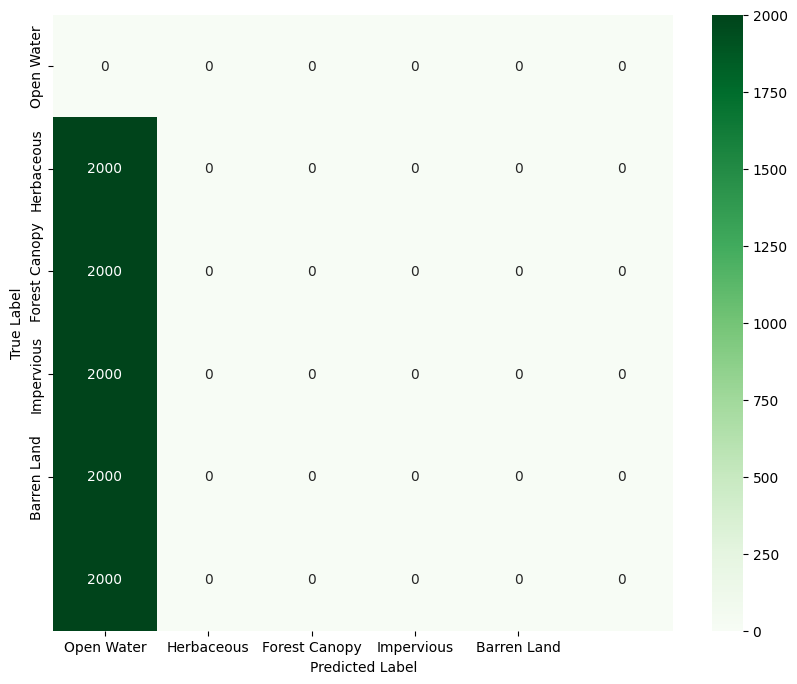

In [4]:
assessment_points_final['pred_lc_class'].value_counts()

confuision_matrix = confusion_matrix(assessment_points_final['lc_class'], assessment_points_final['pred_lc_class'])
print("Confusion Matrix:")
print(confuision_matrix)

print(classification_report(assessment_points_final['lc_class'], assessment_points_final['pred_lc_class']))

# pretty print the confusion matrix with class labels
class_labels = {
    1: 'Open Water',
    2: 'Herbaceous',
    3: 'Forest Canopy',
    4: 'Impervious',
    5: 'Barren Land',
}

import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(confuision_matrix, annot=True, fmt='d', cmap='Greens',
            xticklabels=[class_labels[i] for i in sorted(class_labels.keys())],
            yticklabels=[class_labels[i] for i in sorted(class_labels.keys())], ax=ax)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

# format classification report as a DataFrame for better visualization
report_dict = classification_report(assessment_points_final['lc_class'], assessment_points_final['pred_lc_class'], output_dict=True, target_names=[class_labels[i] for i in sorted(class_labels.keys())])
report_df = pd.DataFrame(report_dict).transpose()
report_df.index.name = 'Class'
report_df = report_df.rename(columns={
    'precision': 'User\'s Accuracy',
    'recall': 'Producer\'s Accuracy',
    'f1-score': 'F1 Score',
    'support': 'N'
})
display(report_df)

In [34]:
assessment_points_final[['state', 'year']].value_counts()

state  year
VA     2021    3834
PA     2022    2467
MD     2021    2329
NY     2022     698
DE     2021     488
WV     2022     165
DC     2021      19
Name: count, dtype: int64